In [1]:
import pandas as pd

# Importacion de datos

In [223]:
# transaccionales
transac = pd.read_csv("muestra_transacciones (1).csv")

# maestra clientes
clientes = pd.read_csv("muestra_customers (2).csv", sep=",", quotechar='"')

In [224]:
with open("muestra_customers (2).csv", "r", encoding="utf-8") as infile, open(
    "muestra_customers.csv", "w", encoding="utf-8"
) as outfile:

    for linea in infile:
        linea_limpia = linea.strip()
        # Si la línea está encerrada en comillas, las quitamos
        if linea_limpia.startswith('"') and linea_limpia.endswith('"'):
            linea_limpia = linea_limpia[1:-1]
            # 4. Aplica la expresión regular a la línea
            linea_limpia = linea_limpia.replace('""BOGOTA, D.C.""', "BOGOTA")
            # print(linea_limpia)

        # Escribe la línea limpia en el nuevo archivo
        outfile.write(linea_limpia + "\n")

In [225]:
clientes = pd.read_csv(
    "muestra_customers.csv", sep=",", quotechar='"', skipinitialspace=True
)

## Exploratorio

### transacciones

In [226]:
transac["fecha"] = pd.to_datetime(transac["fecha"])

# Paso 2: Extraer solo la parte de la fecha (año-mes-día)
transac["fecha"] = transac["fecha"].dt.date

In [227]:
transac.describe()

,id_cliente,id_aliado,id_transaccion,puntos,valor_transaccion
count,2.192100e+04,21921.000000,2.192100e+04,21921.000000,2.093300e+04
mean,3.198273e+08,20.413165,1.599900e+10,202.756124,8.119562e+04
std,2.807254e+08,1.826745,1.676875e+08,2116.384396,3.863086e+05
min,8.149500e+05,0.000000,1.571059e+10,-5637.000000,-2.000000e+04
25%,1.108504e+08,20.000000,1.585562e+10,8.000000,5.200000e+03
50%,2.059398e+08,21.000000,1.599106e+10,25.000000,1.561700e+04
75%,5.305656e+08,21.000000,1.614343e+10,82.000000,4.550000e+04
max,1.228003e+09,21.000000,1.631072e+10,243947.000000,1.528430e+07


In [228]:
transac = transac[transac["puntos"] > 0]
transac = transac[transac["valor_transaccion"] > 0]

In [229]:
transac.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20173 entries, 1 to 21920
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id_cliente         20173 non-null  int64  
 1   fecha              20173 non-null  object 
 2   id_aliado          20173 non-null  int64  
 3   tipo_transaccion   20173 non-null  object 
 4   id_transaccion     20173 non-null  int64  
 5   puntos             20173 non-null  float64
 6   valor_transaccion  20173 non-null  float64
 7   categoria          20173 non-null  object 
dtypes: float64(2), int64(3), object(3)
memory usage: 1.4+ MB


In [230]:
transac["tipo_transaccion"].value_counts()

tipo_transaccion
Sale          19002
Redemption     1171
Name: count, dtype: int64

In [231]:
transac["categoria"].value_counts()

categoria
MERCADO                  5428
COMIDA                   4244
TRANSPORTE               2557
SALUD Y BELLEZA          1536
HOGAR                    1127
MODA                      982
LICORES Y CIGARRILLOS     760
GASTRONOMIA               684
OTROS                     518
TECNOLOGIA                433
VIAJES                    428
MASCOTAS                  419
EDUCACION                 370
ENTRETENIMIENTO           233
MARKETPLACE               172
BANCA                     144
BONOS                     102
DEPORTES                   20
COMIDAS                    14
DEPORTE                     2
Name: count, dtype: int64

In [ ]:
mapeo_categorias = {
    "COMIDAS": "COMIDA",
    "GASTRONOMIA": "ALIMENTACION Y RESTAURANTES",
    "DEPORTE": "DEPORTES",
}

# Aplica el reemplazo
transac["categoria"] = transac["categoria"].replace(mapeo_categorias)

In [233]:
# mapeo_categorias = {
#     "COMIDA": "ALIMENTACION Y RESTAURANTES",
#     "GASTRONOMIA": "ALIMENTACION Y RESTAURANTES",
#     "COMIDAS": "ALIMENTACION Y RESTAURANTES",
#     "SALUD Y BELLEZA": "BIENESTAR Y OCIO",
#     "ENTRETENIMIENTO": "BIENESTAR Y OCIO",
#     "DEPORTES": "OTROS",
#     "DEPORTE": "OTROS",
#     "LICORES Y CIGARRILLOS": "GASTOS VARIOS",
#     "MARKETPLACE": "COMPRAS EN LINEA",
#     "BONOS": "COMPRAS EN LINEA",
#     "TECNOLOGIA": "GASTOS VARIOS",
#     "VIAJES": "GASTOS VARIOS",
#     "MASCOTAS": "GASTOS VARIOS",
#     "EDUCACION": "GASTOS VARIOS",
#     "BANCA": "GASTOS VARIOS",
# }

# # Aplica el reemplazo
# transac["categoria"] = transac["categoria"].replace(mapeo_categorias)

In [235]:
transac["categoria"].value_counts()

categoria
MERCADO                        5428
COMIDA                         4258
TRANSPORTE                     2557
SALUD Y BELLEZA                1536
HOGAR                          1127
MODA                            982
LICORES Y CIGARRILLOS           760
ALIMENTACION Y RESTAURANTES     684
OTROS                           518
TECNOLOGIA                      433
VIAJES                          428
MASCOTAS                        419
EDUCACION                       370
ENTRETENIMIENTO                 233
MARKETPLACE                     172
BANCA                           144
BONOS                           102
DEPORTES                         22
Name: count, dtype: int64

In [236]:
import matplotlib.pyplot as plt

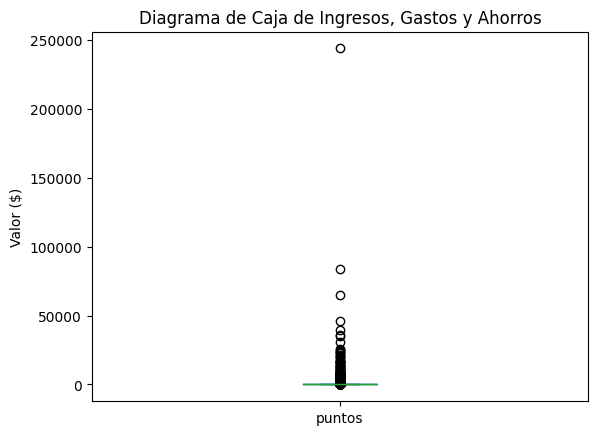

In [237]:
# Crear un boxplot para múltiples variables
transac[["puntos"]].plot.box()
plt.title("Diagrama de Caja de Ingresos, Gastos y Ahorros")
plt.ylabel("Valor ($)")
plt.show()

In [238]:
transac[transac["puntos"] > 10000]

,id_cliente,fecha,id_aliado,tipo_transaccion,id_transaccion,puntos,valor_transaccion,categoria
340,259840150,2021-07-29,20,Sale,15955804698,17272.0,9500000.00,HOGAR
2287,14858350,2021-01-10,21,Redemption,15811881739,15985.0,111898.00,TECNOLOGIA
2305,46601900,2022-05-21,21,Redemption,16222289902,243947.0,1707628.00,TECNOLOGIA
2314,46601900,2020-11-29,21,Redemption,15777625665,14861.0,103092.00,HOGAR
2318,46601900,2020-11-29,21,Redemption,15777625665,30727.0,213149.00,ENTRETENIMIENTO
2346,553812300,2022-04-09,21,Redemption,16185607462,10819.0,68537.00,COMIDA
2365,46601900,2020-10-25,1,Redemption,15753490184,25572.0,179004.00,MODA
4159,349055050,2022-05-16,21,Redemption,16217575569,65266.0,456860.00,OTROS
4617,259840150,2022-02-26,10,Redemption,16145737193,15967.0,95800.00,TRANSPORTE
6503,172206700,2022-03-09,21,Sale,16157364222,11892.0,8325305.00,TECNOLOGIA


In [239]:
# Calcular Q1, Q3 y el IQR
Q1 = transac["valor_transaccion"].quantile(0.25)
Q3 = transac["valor_transaccion"].quantile(0.75)
IQR = Q3 - Q1

# Calcular los límites
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

print(f"Límite Inferior (LI): {limite_inferior:.2f}")
print(f"Límite Superior (LS): {limite_superior:.2f}")

Límite Inferior (LI): -56491.00
Límite Superior (LS): 109869.00


In [240]:
limites = (
    transac.groupby("tipo_transaccion")["valor_transaccion"]
    .agg(
        Q1="quantile", Q3="quantile", IQR=lambda x: x.quantile(0.75) - x.quantile(0.25)
    )
    .reset_index()
)

# Calculamos los límites inferior y superior para cada categoría
limites["limite_inferior"] = limites["Q1"] - 1.5 * limites["IQR"]
limites["limite_superior"] = limites["Q3"] + 1.5 * limites["IQR"]

In [241]:
limites

,tipo_transaccion,Q1,Q3,IQR,limite_inferior,limite_superior
0,Redemption,1564.0,1564.0,4257.0,-4821.5,7949.5
1,Sale,18300.0,18300.0,43200.0,-46500.0,83100.0


#### imputacion de datos transaccionales

In [242]:
imp_valor = transac[transac["puntos"] != 0][
    ["tipo_transaccion", "puntos", "valor_transaccion"]
]

imp_valor["tasa"] = imp_valor["puntos"] / imp_valor["valor_transaccion"]
imp_valor = (
    imp_valor[["tipo_transaccion", "tasa"]].groupby(by=["tipo_transaccion"]).mean()
)

transac = transac.merge(imp_valor, how="left", on=["tipo_transaccion"])

es_nulo = transac["valor_transaccion"].isnull()

transac.loc[es_nulo, "valor_transaccion"] = (
    transac.loc[es_nulo, "puntos"] / transac.loc[es_nulo, "tasa"]
).round(1)

transac.drop(columns=["tasa"], inplace=True)

### maestra de clientes

In [243]:
clientes.drop(columns="id_cliente").describe()

,estrato_social,saldo_puntos
count,462.000000,500.000000
mean,3.387446,1117.836000
std,1.415476,6400.833425
min,2.000000,0.000000
25%,2.000000,0.000000
50%,3.000000,0.000000
75%,4.000000,264.000000
max,6.000000,120702.000000


In [244]:
clientes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id_cliente        500 non-null    int64  
 1   genero            471 non-null    object 
 2   fecha_nacimiento  463 non-null    object 
 3   estrato_social    462 non-null    float64
 4   estado_civil      467 non-null    object 
 5   ocupacion         466 non-null    object 
 6   ciudad            470 non-null    object 
 7   saldo_puntos      500 non-null    int64  
dtypes: float64(1), int64(2), object(5)
memory usage: 31.4+ KB


### imputacion de datos en la maestra

##### ciudad

In [245]:
moda_ciudad = clientes["ciudad"].mode()[0]

print(f"Moda de la columna 'ciudad': {moda_ciudad}")

# Imputar los valores nulos con la moda
clientes["ciudad"].fillna(moda_ciudad, inplace=True)

Moda de la columna 'ciudad': BOGOTA


C:\Users\juaperez\AppData\Local\Temp\ipykernel_34308\1117698747.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  clientes["ciudad"].fillna(moda_ciudad, inplace=True)


In [246]:
clientes["ciudad"].value_counts()

ciudad
BOGOTA          219
MEDELLIN         86
MANIZALES        83
CALI             75
CARTAGENA        18
BARRANQUILLA      9
PEREIRA           8
MANATI            1
ENVIGADO          1
Name: count, dtype: int64

In [247]:
clientes.loc[
    clientes["ciudad"].isin(
        ["CARTAGENA", "BARRANQUILLA", "PEREIRA", "MANATI", "ENVIGADO"]
    ),
    "ciudad",
] = "otros"

In [248]:
clientes["ciudad"].value_counts()

ciudad
BOGOTA       219
MEDELLIN      86
MANIZALES     83
CALI          75
otros         37
Name: count, dtype: int64

##### genero

In [249]:
moda_genero = clientes["genero"].mode()[0]

print(f"Moda de la columna 'genero': {moda_genero}")

# Imputar los valores nulos con la moda
clientes["genero"].fillna(moda_genero, inplace=True)

Moda de la columna 'genero': F


C:\Users\juaperez\AppData\Local\Temp\ipykernel_34308\961310148.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  clientes["genero"].fillna(moda_genero, inplace=True)


In [250]:
clientes["genero"].value_counts()

genero
F    262
M    233
O      5
Name: count, dtype: int64

##### estrato_social

In [251]:
moda_estrato = clientes["estrato_social"].mode()[0]

print(f"Moda de la columna 'estrato_social': {moda_estrato}")

# Imputar los valores nulos con la moda
clientes["estrato_social"].fillna(moda_estrato, inplace=True)

Moda de la columna 'estrato_social': 2.0


C:\Users\juaperez\AppData\Local\Temp\ipykernel_34308\3248794809.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  clientes["estrato_social"].fillna(moda_estrato, inplace=True)


In [252]:
clientes["estrato_social"].value_counts()

estrato_social
2.0    198
3.0    142
6.0     68
4.0     49
5.0     43
Name: count, dtype: int64

##### estado_civil

In [253]:
moda_estado_civil = clientes["estado_civil"].mode()[0]

print(f"Moda de la columna 'estado_civil': {moda_estado_civil}")

# Imputar los valores nulos con la moda
clientes["estado_civil"].fillna(moda_estado_civil, inplace=True)

Moda de la columna 'estado_civil': Casado


C:\Users\juaperez\AppData\Local\Temp\ipykernel_34308\285110684.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  clientes["estado_civil"].fillna(moda_estado_civil, inplace=True)


In [254]:
clientes["estado_civil"].value_counts()

estado_civil
Casado         255
Soltero        114
Divorciado      44
Otro            32
Separado        30
Union Libre     18
No Informa       6
Viudo            1
Name: count, dtype: int64

In [255]:
clientes.loc[
    clientes["estado_civil"].isin(["Otro", "Union Libre", "No Informa", "Viudo"]),
    "estado_civil",
] = "otros"

clientes.loc[
    clientes["estado_civil"].isin(["Separado"]),
    "estado_civil",
] = "Divorciado"

In [256]:
clientes["estado_civil"].value_counts()

estado_civil
Casado        255
Soltero       114
Divorciado     74
otros          57
Name: count, dtype: int64

##### ocupacion

In [257]:
moda_ocupacion = clientes["ocupacion"].mode()[0]

print(f"Moda de la columna 'ocupacion': {moda_ocupacion}")

# Imputar los valores nulos con la moda
clientes["ocupacion"].fillna(moda_ocupacion, inplace=True)

Moda de la columna 'ocupacion': Empleado


C:\Users\juaperez\AppData\Local\Temp\ipykernel_34308\3873021494.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  clientes["ocupacion"].fillna(moda_ocupacion, inplace=True)


In [258]:
clientes["ocupacion"].value_counts()

ocupacion
Empleado               280
Independiente           98
Ama de Casa             47
Estudiante              27
Comerciante             24
Otro                     9
Ama de Casa              8
Jubilado                 6
Rentista de Capital      1
Name: count, dtype: int64

In [259]:
clientes.loc[
    clientes["ocupacion"].isin(
        ["Otro", "Jubilado", "Rentista de Capital", "Comerciante", "Estudiante"]
    ),
    "ocupacion",
] = "otros"

clientes.loc[
    clientes["ocupacion"].isin(
        [
            "Ama de Casa",
            "Ama de Casa  ",
        ]
    ),
    "ocupacion",
] = "Ama de Casa"

In [260]:
clientes["ocupacion"].value_counts()

ocupacion
Empleado         280
Independiente     98
otros             67
Ama de Casa       55
Name: count, dtype: int64

In [261]:
transac[transac["id_cliente"] == 409046800].sort_values("fecha").tail(50)

,id_cliente,fecha,id_aliado,tipo_transaccion,id_transaccion,puntos,valor_transaccion,categoria
11520,409046800,2021-02-02,21,Sale,15827154453,47.0,33480.0,MERCADO
11519,409046800,2021-02-02,21,Sale,15827154453,151.0,106507.0,MERCADO
5530,409046800,2021-03-01,21,Sale,15847833143,188.0,132322.0,MERCADO
5523,409046800,2021-03-01,21,Sale,15847833143,59.0,42090.0,HOGAR
5529,409046800,2021-03-01,21,Sale,15847833143,9.0,6500.0,MERCADO
5525,409046800,2021-03-01,21,Sale,15847833143,2.0,1800.0,COMIDA
5526,409046800,2021-03-01,21,Sale,15847833143,23.0,16740.0,MERCADO
5524,409046800,2021-03-01,21,Sale,15847833143,45.0,31750.0,SALUD Y BELLEZA
5527,409046800,2021-03-01,21,Sale,15847833143,2.0,1600.0,COMIDA
5532,409046800,2021-03-01,21,Sale,15847833143,17.0,12480.0,COMIDA


### descripcion de clientes

In [262]:
print(
    f"""
      Cantidad de clientes en la tabla de trasacciones: 
      {clientes["id_cliente"].nunique()}
      Cantidad de clientes en la maestra de clientes:
      {transac["id_cliente"].nunique()}
"""
)


      Cantidad de clientes en la tabla de trasacciones: 
      500
      Cantidad de clientes en la maestra de clientes:
      220



¿A que se debe que la tabla de clientes tenga más clientes unicos que la tabla maestra?

* Pueden ser clientes nuevos que aún no se encuentran registrados en las maestras, esto puede ser causado por una falta de sincronizacion en las tablas o que provienen de partes distintas, aun así esto no deberia pasar.

* clientes mal ingresado a las bases de datos que tambien seria una falla grave en la tabla de transacciones

En estos casos lo mejor es quedarse con los clientes que si estan en las tablas maestras ya que son clientes validados y el objetivo de los modelos es entregar un resultado para estos

### union de tablas

In [263]:
transac["id_cliente"] = transac["id_cliente"].astype(int)

In [264]:
clientes["id_cliente"] = clientes["id_cliente"].astype(int)

In [265]:
datos = transac.merge(clientes, how="inner", on=["id_cliente"])

In [266]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20173 entries, 0 to 20172
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id_cliente         20173 non-null  int64  
 1   fecha              20173 non-null  object 
 2   id_aliado          20173 non-null  int64  
 3   tipo_transaccion   20173 non-null  object 
 4   id_transaccion     20173 non-null  int64  
 5   puntos             20173 non-null  float64
 6   valor_transaccion  20173 non-null  float64
 7   categoria          20173 non-null  object 
 8   genero             20173 non-null  object 
 9   fecha_nacimiento   19112 non-null  object 
 10  estrato_social     20173 non-null  float64
 11  estado_civil       20173 non-null  object 
 12  ocupacion          20173 non-null  object 
 13  ciudad             20173 non-null  object 
 14  saldo_puntos       20173 non-null  int64  
dtypes: float64(3), int64(4), object(8)
memory usage: 2.3+ MB


In [267]:
datos.to_csv("datos_train.csv", index=False)